In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, add_dummy_feature

### Первоначальный анализ данных

In [2]:
df = pd.read_csv("data/well_data.csv")
df = df.drop(columns=["well_id"])

display(df.head())
display(df.info())
display(df.describe())

,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   porosity               200 non-null    float64
 1   permeability           200 non-null    float64
 2   acoustic_impedance     200 non-null    float64
 3   brittleness            200 non-null    float64
 4   organic_carbon         200 non-null    float64
 5   vitrinite_reflectance  200 non-null    float64
 6   extr_per_day           200 non-null    float64
dtypes: float64(7)
memory usage: 11.1 KB


None

,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


Статистика для porosity:
Среднее: 14.99
Стандартное отклонение: 2.97
Скос: -0.20
Смещение: -0.02
Нормальность распределения: 0.99

Статистика для permeability:
Среднее: 4.33
Стандартное отклонение: 1.73
Скос: 0.86
Смещение: 0.85
Нормальность распределения: 0.95

Статистика для acoustic_impedance:
Среднее: 2.97
Стандартное отклонение: 0.57
Скос: 0.00
Смещение: 0.20
Нормальность распределения: 0.99

Статистика для brittleness:
Среднее: 48.16
Стандартное отклонение: 14.13
Скос: -0.27
Смещение: -0.40
Нормальность распределения: 0.99

Статистика для organic_carbon:
Среднее: 0.99
Стандартное отклонение: 0.48
Скос: -0.14
Смещение: -0.47
Нормальность распределения: 0.99

Статистика для vitrinite_reflectance:
Среднее: 1.96
Стандартное отклонение: 0.30
Скос: 0.04
Смещение: 0.80
Нормальность распределения: 0.99

Статистика для extr_per_day:
Среднее: 4311.22
Стандартное отклонение: 992.04
Скос: 0.07
Смещение: -0.52
Нормальность распределения: 0.99



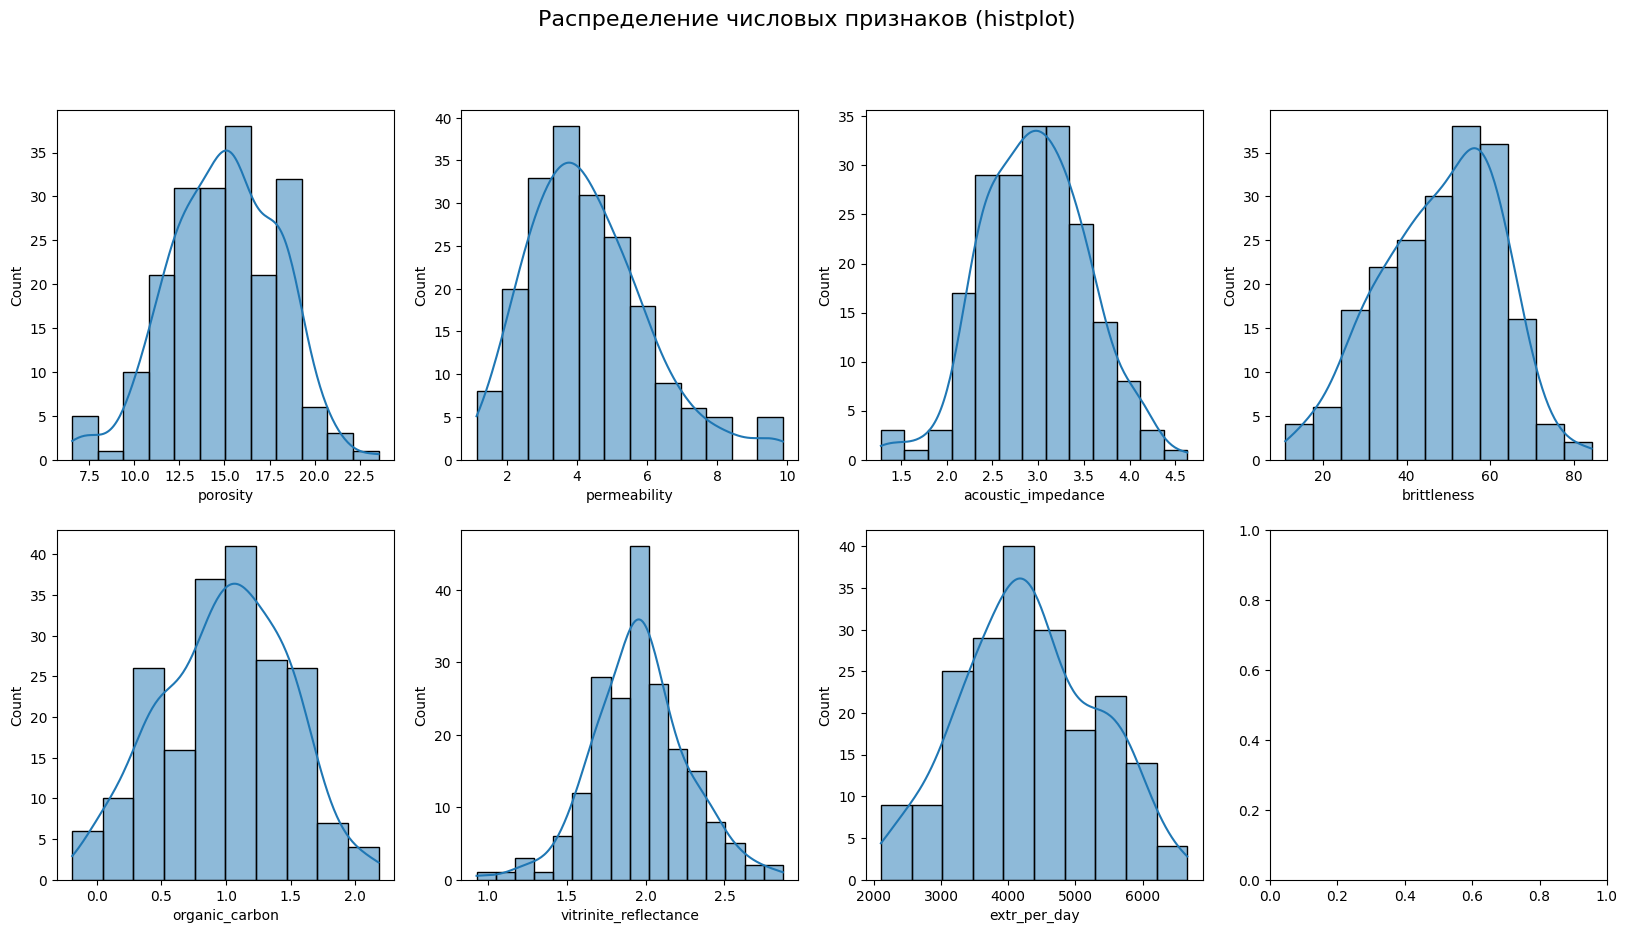

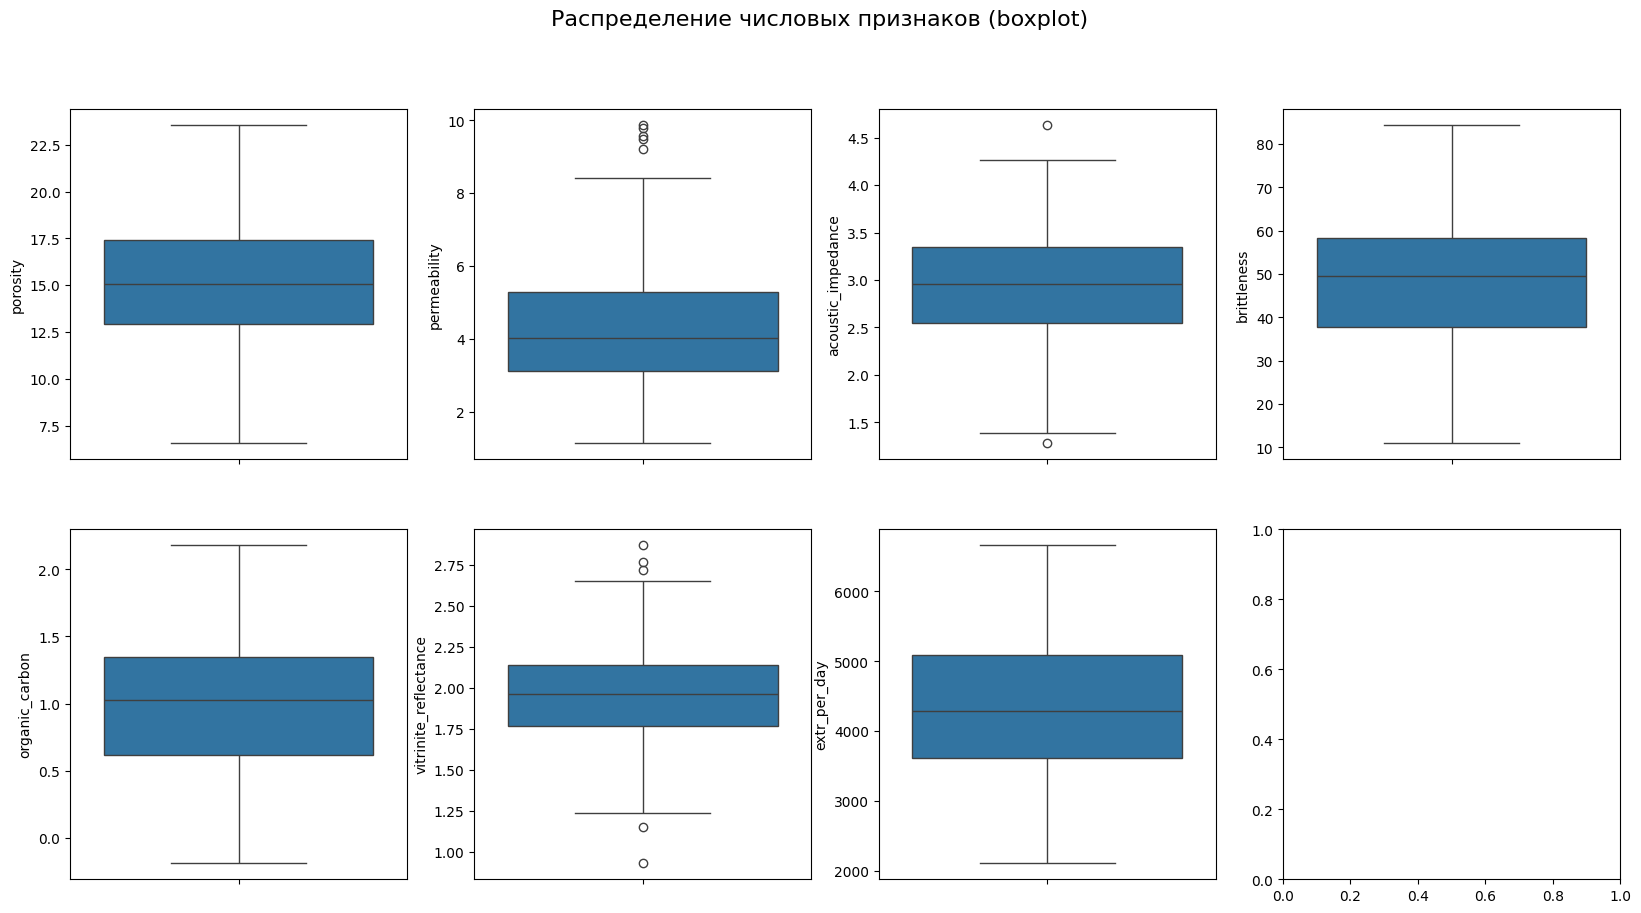

In [3]:
def plot_numerical_distributions(df: pd.DataFrame, cols_per_row: int = 4) -> None:
    """
    Строит histplot и boxplot для всех числовых колонок DataFrame
    """
    df_cols = df.columns
    n_cols = len(df_cols)
    rows = math.ceil(n_cols / cols_per_row)
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 5*rows))
    fig.suptitle("Распределение числовых признаков (histplot)", fontsize=16)

    axes = axes.flatten()
    
    for idx, col in enumerate(df_cols):
        ax = axes[idx]
        sns.histplot(data=df, x=col, ax=ax, kde=True)
        
        mean = df[col].mean()
        std = df[col].std()
        skew = df[col].skew()
        kurt = df[col].kurt()
        norm = stats.shapiro(df[col])
        print(
            f"Статистика для {col}:\n"
            f"Среднее: {mean:.2f}\n"
            f"Стандартное отклонение: {std:.2f}\n"
            f"Скос: {skew:.2f}\n"
            f"Смещение: {kurt:.2f}\n"
            f"Нормальность распределения: {norm.statistic:.2f}\n"
        )
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 5*rows))
    fig.suptitle("Распределение числовых признаков (boxplot)", fontsize=16)
    axes = axes.flatten()
    
    for idx, col in enumerate(df_cols):
        ax = axes[idx]
        sns.boxplot(data=df, y=col, ax=ax)


plot_numerical_distributions(df)

In [4]:
dupl = df.duplicated().sum()
print(f"Найдено дубликатов строк: {dupl}.\n")

if dupl:
    df = df.drop_duplicates()
    print("Дубликаты удалены из данных.\n")

nan = df.isna().sum()
print(f"Пропущенные значения: \n{nan}")

Найдено дубликатов строк: 0.

Пропущенные значения: 
porosity                 0
permeability             0
acoustic_impedance       0
brittleness              0
organic_carbon           0
vitrinite_reflectance    0
extr_per_day             0
dtype: int64


**Вывод:**  
В данных отсутствуют пропуски, дубликаты строк. Все типы соответствуют ожидаемым. Распределения очень близки к нормальным, но более плоские; в некоторых случаях наблюдается небольшое смещение и островершинность. Признак `permeability` содержит наибольшее количество выбросов, что и объясняет правостороннюю ассимметрию.

### EDA

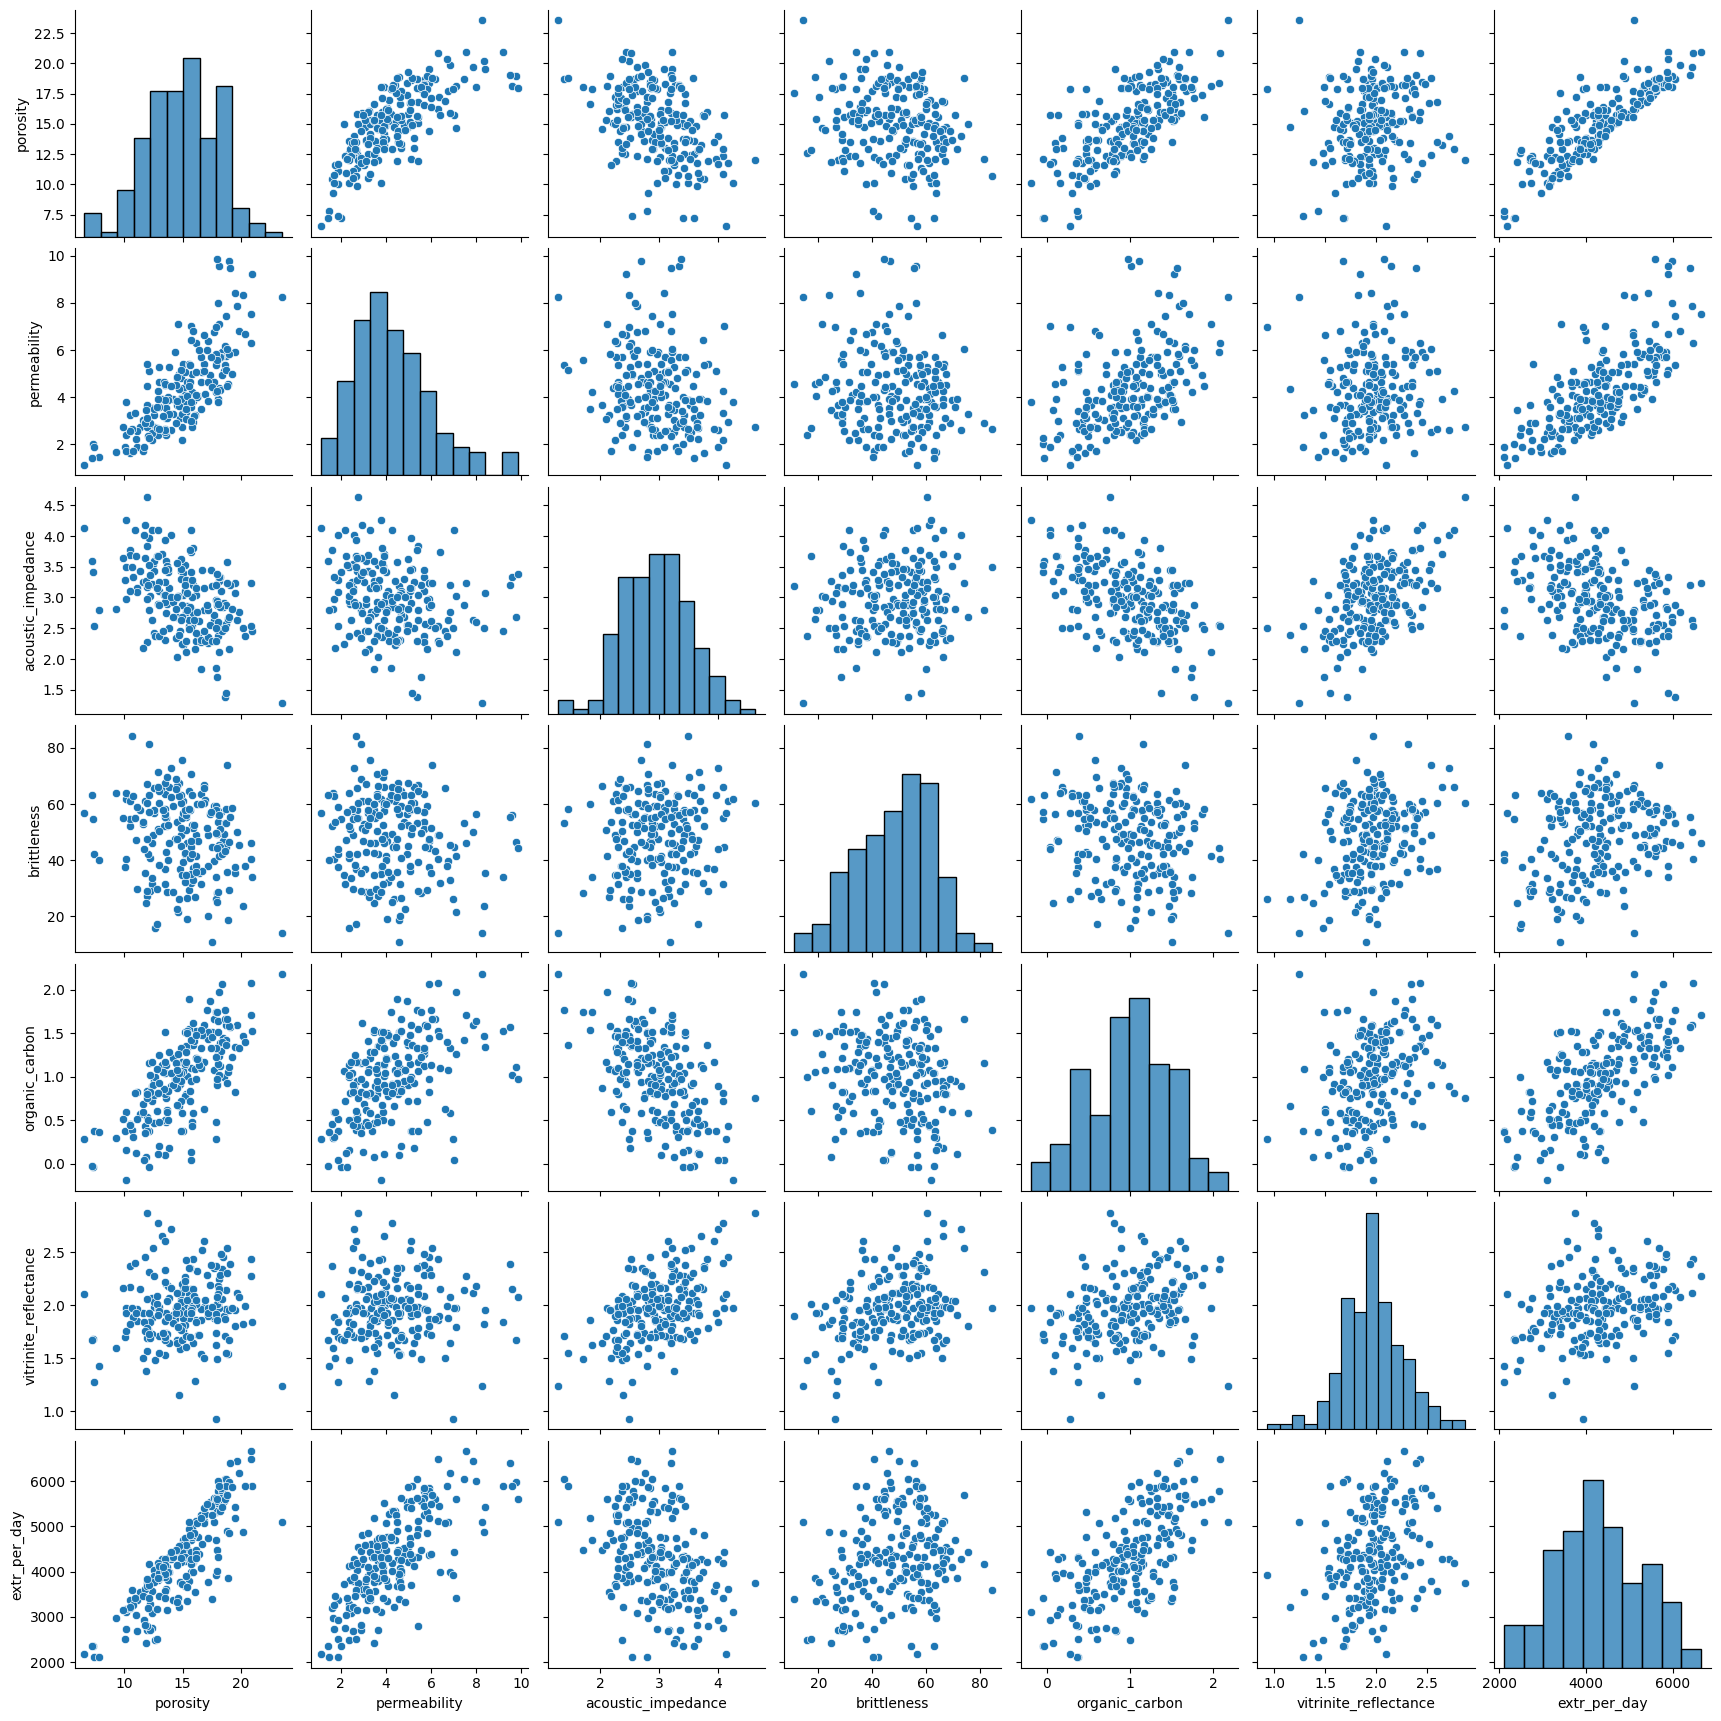

In [5]:
sns.pairplot(df)

<Axes: >

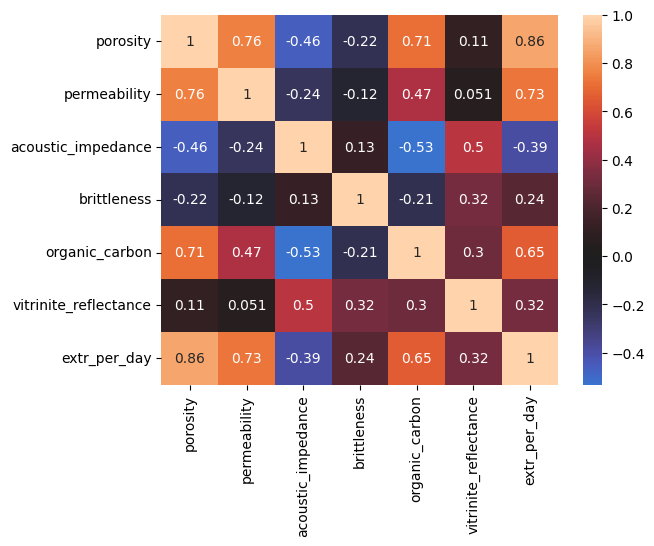

In [6]:
corr = df.corr()

sns.heatmap(corr, annot=True, center=0.0)

**Вывод:**  
- Наиболее коррелирующие с целевой меткой признаки: `porosity (0.86)`, `permeability (0.73)`, `organic_carbon (0.65)`.
- 
- Однако, пары `permeability/porosity (0.76)` и `organic_carbon/porosity (0.71)` так же имеют высокую корреляцию между собой. Выбор того, какой признак убрать, затрудняется тем, что общий для пар признак `porosity` имеет наибольшую связь с целевым; в то же время, признак `permeability` имеет наибольшее количество выбросов.
- 
- Поэтому я буду исходить из того, что последующее удаление признака `porosity` избавит меня от мультиколлинеарности и улучшит обобщающую способность модели, а его высокая корреляция перераспределится на два оставшихся признака.

p.s.  
Дальше я понял, что это ключевой признак, но на момент написания вывода это казалось не так очевидно

### Разделение данных и их преобразование

In [7]:
df_1 = df.drop(columns=["porosity"])
print("Оставшиеся признаки:", df_1.columns.to_list())

target = "extr_per_day"
feature_cols = df_1.drop(target, axis=1).columns

X = df_1.drop(target, axis=1).values
y = df_1[target].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_bias = add_dummy_feature(X_train_scaled)
X_test_bias = add_dummy_feature(X_test_scaled)

Оставшиеся признаки: ['permeability', 'acoustic_impedance', 'brittleness', 'organic_carbon', 'vitrinite_reflectance', 'extr_per_day']


In [8]:
print("Обучающая выборка после преобразований:\n", X_train_bias[:3])
print("Тестовая выборка после преобразований:\n", X_test_bias[:3])

Обучающая выборка после преобразований:
 [[ 1.         -0.24286837 -0.91523176  0.66154043  0.3285037   0.10076757]
 [ 1.         -1.16794607  0.96193752  0.62832758 -2.15747021 -0.82241999]
 [ 1.         -0.3734008   0.96193752 -0.44242587  0.30761316  0.92504218]]
Тестовая выборка после преобразований:
 [[ 1.         -0.03855673 -0.20011965  0.0752614  -0.15197866  0.10076757]
 [ 1.         -0.91255652  0.80103729  0.69764136 -0.88314745  0.56236135]
 [ 1.          0.90922227 -0.23587526 -0.10668726  0.95521981  1.55149088]]


**Вывод:**  
Выбор стандартизации данных обусловлен следующим:
- привести все значения признаков к одному масштабу
- улучшает сходимость градиентных методов
- регуляризация штрафует все признаки одинаково, поэтому важен их масштаб

## Проверка различных реализаций линейной регрессии

In [9]:
class ScoresMixin:

    def scores(self, y_test: np.ndarray, y_pred: np.ndarray) -> None:
        """Вывод основных метрик модели."""
        print(
            f"MSE: {mean_squared_error(y_test, y_pred):.4f}\n"
            f"MAE: {mean_absolute_error(y_test, y_pred):.4f}\n"
            f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}\n"
            f"R^2: {r2_score(y_test, y_pred):.4f}\n"
        )

scores_mixin = ScoresMixin()

In [10]:

class SimpleSquareRegression(ScoresMixin):
    """Реализация алгоритма линейной регрессии МНК."""

    def fit(self, X_bias: np.ndarray, y: np.ndarray) -> None:
        self.weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
    
    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return X_test @ self.weights

    def get_coef(self, feature_col_names: pd.Index) -> pd.DataFrame:
        coef_names = pd.Index(["Intercept"]).append(feature_col_names)
        return pd.DataFrame({
            "Признаки": coef_names,
            "Коэффициенты": self.weights.tolist(),
        })

mse_reg = SimpleSquareRegression()
mse_reg.fit(X_train_bias, y_train)

y_train_pred = mse_reg.predict(X_train_bias)
y_test_pred = mse_reg.predict(X_test_bias)

print("Метрики на обучающей выборке:")
mse_reg.scores(y_train, y_train_pred)

print("Метрики на тестовой выборке:")
mse_reg.scores(y_test, y_test_pred)

mse_reg.get_coef(feature_cols)

Метрики на обучающей выборке:
MSE: 156244.4205
MAE: 312.3493
MAPE: 0.0752
R^2: 0.8454

Метрики на тестовой выборке:
MSE: 112379.0568
MAE: 263.3939
MAPE: 0.0636
R^2: 0.8672



,Признаки,Коэффициенты
0,Intercept,[4330.32511519375]
1,permeability,[598.5610205885787]
2,acoustic_impedance,[-436.78172249799445]
3,brittleness,[248.2349215282425]
4,organic_carbon,[70.56666078858285]
5,vitrinite_reflectance,[408.04178522735276]


In [11]:
sk_lin_model = LinearRegression()
sk_lin_model.fit(X_train_scaled, y_train)

sk_y_train_pred = sk_lin_model.predict(X_train_scaled)
sk_y_test_pred = sk_lin_model.predict(X_test_scaled)

print("Метрики на обучающей выборке:")
scores_mixin.scores(y_train, sk_y_train_pred)

print("Метрики на тестовой выборке:")
scores_mixin.scores(y_test, sk_y_test_pred)

print(sk_lin_model.intercept_)
print(sk_lin_model.coef_)

Метрики на обучающей выборке:
MSE: 156244.4205
MAE: 312.3493
MAPE: 0.0752
R^2: 0.8454

Метрики на тестовой выборке:
MSE: 112379.0568
MAE: 263.3939
MAPE: 0.0636
R^2: 0.8672

[4330.32511519]
[[ 598.56102059 -436.7817225   248.23492153   70.56666079  408.04178523]]


**Вывод:**  
- Решение отказаться от сильно скоррелированного, но с самым высоким влиянием на целевой показатель, признака `porosity` оказалось вполне верным. Модель хорошо обобщает данные, отсутствует переобучение (`R^2 train (0.8454) | test (0.8672)`), объясняет более ~86.7% дисперсии.
- Разницы в результатах при ручной реализации алгоритма и его реализации в sklearn никакой нет.
- Несмотря на то, что `organic_carbon` имел высокую корреляцию с целевым признаком `(0.65)`, по итогу получил самый низкий коффициент среди прочих. Получается, что большая часть его предсказательной силы уловно оказалась учтена через другие признаках.

p.s.  
От сделанных ранее выводов все же решил не отказываться, так как на тот момент думал, что они верные. Ошибочность суждения выявило дальнейшее задание с регуляризацией.

### Ручная реализация классического градиентного спуска с возможностью обучения на мини-батче

In [12]:
class SimpleGradientDescent(ScoresMixin):
    """Реализация алгоритма градиента спуска с возможностью обучения на выборке"""

    def __init__(
        self,
        n_iter: int = 1000,
        learning_rate: float = 0.01,
        batch_size: int | None = None,
        seed: int = 42,
    ) -> None:
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.losses = []
        self.rng = np.random.default_rng(seed)

    def _update_weights_and_bias(self, X: np.ndarray, y: np.ndarray) -> float:
        n_samples = X.shape[0]
        y_pred = self.predict(X)

        error = y_pred - y
        dw = (2 / n_samples) * X.T @ error
        
        self.weights -= self.learning_rate * dw
        
        return error

    def _get_mini_batch(self, X: np.ndarray, y: np.ndarray):
        n_samples = X.shape[0]
        indices = self.rng.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, self.batch_size):
            end = min(start + self.batch_size, n_samples)
            yield X_shuffled[start:end], y_shuffled[start:end]

    def _mse_loss(self, error: np.ndarray) -> float:
        return np.mean(error ** 2)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        y = y.flatten()
        n_features = X.shape[1]
        
        self.weights = self.rng.normal(0, 0.01, n_features)

        for _ in range(self.n_iter):
            
            if self.batch_size:
                for X_b, y_b in self._get_mini_batch(X, y):
                    error = self._update_weights_and_bias(X_b, y_b)
                    loss = self._mse_loss(error)
                    self.losses.append(loss)

            else:
                error = self._update_weights_and_bias(X, y)
                loss = self._mse_loss(error)
                self.losses.append(loss)
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights
    
    def get_coef(self, feature_col_names: pd.Index) -> pd.DataFrame:
        coef_names = pd.Index(["Intercept"]).append(feature_col_names)
        return pd.DataFrame({
            "Признаки": coef_names,
            "Коэффициенты": self.weights,
        })

gd_base_model = SimpleGradientDescent(learning_rate=0.1, n_iter=1000)
gd_batch_model = SimpleGradientDescent(n_iter=200, batch_size=20)

In [13]:
%%timeit
gd_base_model.fit(X_train_bias, y_train)

10.8 ms ± 223 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
%%timeit
gd_batch_model.fit(X_train_bias, y_train)

19 ms ± 172 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
y_train_pred_base = gd_base_model.predict(X_train_bias)
y_test_pred_base = gd_base_model.predict(X_test_bias)

y_train_pred_batch = gd_batch_model.predict(X_train_bias)
y_test_pred_batch = gd_batch_model.predict(X_test_bias)

print("Полный батч, метрики на обучающей выборке:")
gd_base_model.scores(y_train, y_train_pred)

print("Полный батч, метрики на тестовой выборке:")
gd_base_model.scores(y_test, y_test_pred)

print("Мини батч, метрики на обучающей выборке:")
gd_batch_model.scores(y_train, y_train_pred_batch)

print("Мини батч, метрики на тестовой выборке:")
gd_batch_model.scores(y_test, y_test_pred_batch)

Полный батч, метрики на обучающей выборке:
MSE: 156244.4205
MAE: 312.3493
MAPE: 0.0752
R^2: 0.8454

Полный батч, метрики на тестовой выборке:
MSE: 112379.0568
MAE: 263.3939
MAPE: 0.0636
R^2: 0.8672

Мини батч, метрики на обучающей выборке:
MSE: 156661.8233
MAE: 313.3349
MAPE: 0.0755
R^2: 0.8450

Мини батч, метрики на тестовой выборке:
MSE: 117627.1349
MAE: 268.9430
MAPE: 0.0648
R^2: 0.8610



In [16]:
gd_base_model.get_coef(feature_cols)

,Признаки,Коэффициенты
0,Intercept,4330.325115
1,permeability,598.557904
2,acoustic_impedance,-436.763364
3,brittleness,248.242430
4,organic_carbon,70.586148
5,vitrinite_reflectance,408.022802


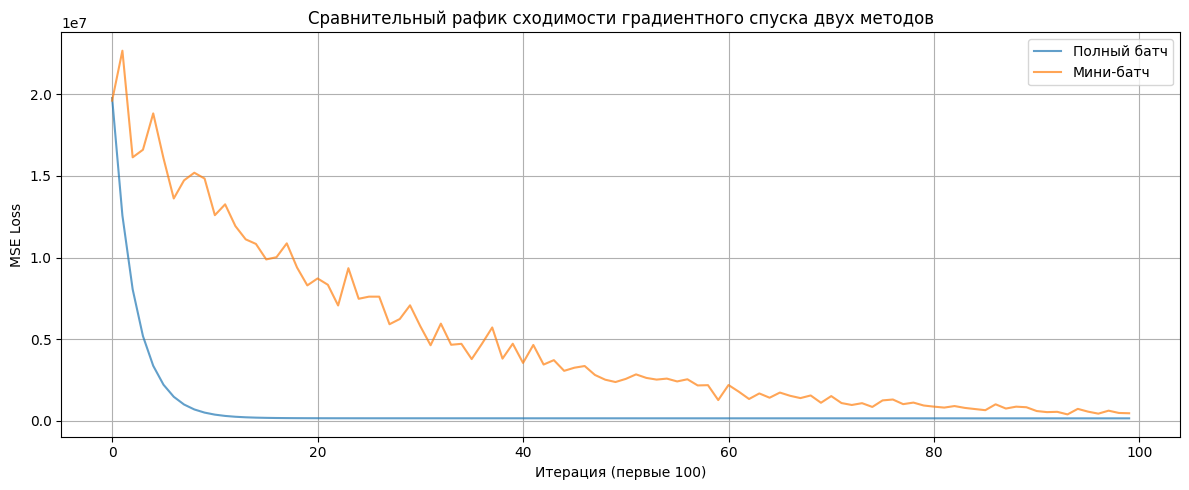

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(gd_base_model.losses[:100], label="Полный батч", alpha=0.7)
plt.plot(gd_batch_model.losses[:100], label="Мини-батч", alpha=0.7)

plt.xlabel("Итерация (первые 100)")
plt.ylabel("MSE Loss")
plt.title("Сравнительный рафик сходимости градиентного спуска двух методов")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Вывод:**  
- Улучшить прогноз не удалось, но получилось получить практически идентичный результат, используя полный градиентный спуск.Это связано с тем, что аналитическое решение МНК дает глобальный минимум для линейной регрессии.
- Классический градиентный спуск или МНК следует использовать в случае, когда данных не очень много; в большинстве случаев, предпочтение лучше отдать мини-батчам, так как это в значительной степени экономит память и ускоряет сходимость в пересчете на количество итераций (в нашем случае наоборот замедлил, так как данных очень мало, а итераций много из-за эпох).

### Использование регуляризации без удаления мультиколлинеарных признаков

In [18]:
target = "extr_per_day"
feature_cols = df.drop(target, axis=1).columns

X = df.drop(target, axis=1).values
y = df[target].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_bias = add_dummy_feature(X_train_scaled)
X_test_bias = add_dummy_feature(X_test_scaled)

In [19]:
best_model = SimpleGradientDescent(learning_rate=0.1, n_iter=1000)
l1_model = Lasso(alpha=50)
l2_model = Ridge(alpha=10)

best_model.fit(X_train_bias, y_train)
l1_model.fit(X_train_scaled, y_train)
l2_model.fit(X_train_scaled, y_train)

best_model_y_pred = best_model.predict(X_test_bias)
l1_model_y_pred = l1_model.predict(X_test_scaled)
l2_model_y_pred = l2_model.predict(X_test_scaled)

In [20]:
print("Метрики лучшей модели:")
best_model.scores(y_test, best_model_y_pred)

print("Метрики модели с L1-регуляризацией:")
scores_mixin.scores(y_test, l1_model_y_pred)

print("Метрики модели с L2-регуляризацией:")
scores_mixin.scores(y_test, l2_model_y_pred)

Метрики лучшей модели:
MSE: 41802.3360
MAE: 144.8023
MAPE: 0.0334
R^2: 0.9506

Метрики модели с L1-регуляризацией:
MSE: 65081.2379
MAE: 184.5483
MAPE: 0.0437
R^2: 0.9231

Метрики модели с L2-регуляризацией:
MSE: 48999.2902
MAE: 163.3513
MAPE: 0.0377
R^2: 0.9421



In [21]:
print("Коэффициенты без регуляризации")
display(best_model.get_coef(feature_cols))

print("Коэффициенты с L1-регуляризацией")
display(l1_model.intercept_, l1_model.coef_)

print("Коэффициенты с L2-регуляризацией")
display(l2_model.intercept_, l2_model.coef_)

Коэффициенты без регуляризации


,Признаки,Коэффициенты
0,Intercept,4330.325115
1,porosity,685.192396
2,permeability,200.020109
3,acoustic_impedance,-177.358102
4,brittleness,355.219695
5,organic_carbon,-0.991124
6,vitrinite_reflectance,195.853572


Коэффициенты с L1-регуляризацией


array([4330.32511519])

array([708.27260233, 130.83461104,  -0.        , 361.00061014,
       117.51640153,  13.74656815])

Коэффициенты с L2-регуляризацией


array([4330.32511519])

array([ 587.38148643,  232.99551586, -150.61182481,  339.79987835,
         69.27928857,  163.97452148])

**Вывод:**  
- Лучше использовать регуляризацию, а не удалять признаки вручную (иначе можно убрать важные признаки только основываясь на взаимной корреляции). L2-регуляризация сама может решить проблемум мультиколлинеарности, сохранив все признаки.
- По итогу, убранный мною признак оказался самым важным при любых обстоятельствах, даже не смотря на попарную корреляцию с другими признаками
- Основные признаки для модели: `porosity`, `brittleness`, `permeability`

### Реализация с алгоритмом RMSProp и ранней остановкой

In [22]:
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

In [23]:
class SimpleRMSProp(ScoresMixin):
    """Реализация алгоритма RMSProp."""

    def __init__(
        self,
        n_iter: int = 1000,
        learning_rate: float = 0.01,
        epsilon: float = 1e-6,
        beta: float = 0.99,
        batch_size: int | None = None,
        patience: int = 5,
        early_stopping: bool = False,
        seed: int = 42,
    ) -> None:
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.epsilon = epsilon
        self.beta = beta
        self.batch_size = batch_size
        self.patience = patience
        self.early_stopping = early_stopping
        self.losses = []
        self.counter = 0
        self.best_loss = np.inf
        self.rng = np.random.default_rng(seed)

    def _update_weights_and_bias(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        n_samples = X.shape[0]

        y_pred = self.predict(X)
        error = y_pred - y
        dw = (2 / n_samples) * X.T @ error
        
        self.cache = self.beta * self.cache + (1 - self.beta) * dw**2
        self.weights -= self.learning_rate * dw / (np.sqrt(self.cache) + self.epsilon)

        return error

    def _get_mini_batch(self, X: np.ndarray, y: np.ndarray):
        n_samples = X.shape[0]
        indices = self.rng.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, self.batch_size):
            end = min(start + self.batch_size, n_samples)
            yield X_shuffled[start:end], y_shuffled[start:end]

    def _check_early_stopping(self) -> bool:
        if self.best_loss - self.losses[-1] > self.epsilon:
            self.best_loss = self.losses[-1]
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def _mse_loss(self, error: np.ndarray) -> float:
        return np.mean(error ** 2)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        y = y.flatten()
        n_features = X.shape[1]
        
        self.weights = self.rng.normal(0, 0.01, n_features)
        self.cache = np.zeros(n_features)

        for i in range(self.n_iter):
            
            if self.batch_size:
                for X_b, y_b in self._get_mini_batch(X, y):
                    error = self._update_weights_and_bias(X_b, y_b)
                    loss = self._mse_loss(error)
                    self.losses.append(loss)

            else:
                error = self._update_weights_and_bias(X, y)
                loss = self._mse_loss(error)
                self.losses.append(loss)

            if self.early_stopping:
                if self._check_early_stopping():
                    print(f"Ранняя остановка на {i} итерации, MSE: {self.losses[-1]:.4f}")
                    break

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights
    
    def get_coef(self, feature_col_names: pd.Index) -> pd.DataFrame:
        return pd.DataFrame({
            "Признаки": feature_col_names,
            "Коэффициенты": self.weights,
        })

rmsprop_model = SimpleRMSProp(
    n_iter=1000,
    learning_rate=0.001,
    epsilon=1e-8,
    beta=0.9,
    early_stopping=True,
)

In [24]:
rmsprop_model.fit(X_train_scaled, y_train_scaled)

rmsprop_y_test_pred = rmsprop_model.predict(X_test_scaled)
rmsprop_y_train_pred = rmsprop_model.predict(X_train_scaled)

print("Метрики на обучающей выборке:")
rmsprop_model.scores(y_train_scaled, rmsprop_y_train_pred)

print("Метрики на тестовой выборке:")
rmsprop_model.scores(y_test_scaled, rmsprop_y_test_pred)

Ранняя остановка на 785 итерации, MSE: 0.0389
Метрики на обучающей выборке:
MSE: 0.0389
MAE: 0.1553
MAPE: 0.9258
R^2: 0.9611

Метрики на тестовой выборке:
MSE: 0.0411
MAE: 0.1435
MAPE: 1.1643
R^2: 0.9509



In [25]:
rmsprop_model.get_coef(feature_cols)

,Признаки,Коэффициенты
0,porosity,0.681004
1,permeability,0.198564
2,acoustic_impedance,-0.176279
3,brittleness,0.353701
4,organic_carbon,-0.001830
5,vitrinite_reflectance,0.195675


**Вывод:**  
Улучшить качество относительно аналитического решения МНК не удалось, так как для линейной регрессии МНК дает глобальный минимум, а градиентные методы только пытаются прийти к нему. Удаление признаков вручную ухудшает модель (в моем случае точно), а адаптивные методы оптимизации не дают преимущества перед аналитическим решением для данной задачи.